
# Code:You Data Analysis Capstone Project
## Agricultural Intensity vs Economic Well-Being: Does farming influence the economic well-being of the community?
## by Peter Reppen




### Import Packages

In [387]:
# import libraries

import pandas as pd
import sqlite3
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# environment also requires pip install pandas openpyxl (for excel spreadsheet)

#### Loading Data Files

##### US Crop Data for 2023:

- 2023 acreage data as of January 2, 2024
- Downloaded from https://www.fsa.usda.gov/tools/informational/freedom-information-act-foia/electronic-reading-room/frequently-requested/crop-acreage-data

##### US Census & USDA Data:
- Poverty estimates for the United States, States, and counties, 2023
-- U.S. Census Bureau's Small Area Income and Poverty Estimate (SAIPE) program
- Unemployment and median household income for the United States, States, and counties, 2000–23
-- source: Bureau of Labor Statistics (BLS) Local Area Unemployment Statistics (LAUS) program
- Population estimates for the United States, States, and counties, 2020–23
-- U.S. Census Bureau, Population Estimates Program: 1990–2000 intercensal tables, 2000–2010 intercensal tables, and vintage 2020 and 2023 population estimates
- Downloaded from:https://www.ers.usda.gov/data-products/county-level-data-sets/county-level-data-sets-download-data

##### FIPS Code: All datasets in this analysis use FIPS Codes
- Federal Information Processing System (FIPS) Codes for States and Counties
- FIPS codes are numbers which uniquely identify geographic areas



In [388]:
# load data (excel spreadsheet)

crop_df = pd.read_excel("../data/2023_fsa_acres_web_010224.xlsx", sheet_name='county_data')
poverty_df = pd.read_excel("../data/Poverty2023.xlsx", sheet_name='Poverty Data 2023')
pop_df = pd.read_excel("../data/PopulationEstimates.xlsx", sheet_name='Population')
unemploy_df = pd.read_excel("../data/Unemployment2023.xlsx", sheet_name='Unemployment Med HH Income')


### Exploring the Data Sets

crop_df (2023_fsa_acres_web_010224.xlsx)

This dataset includes crop related information by State/County 


In [389]:
# exploring crops dataset

crop_df.head(10)

,State Code,County Code,Crop Code,State,County,State County Code,Crop,Crop Type,Intended Use,Irrigation Practice,Planted Acres,Volunteer Acres,Failed Acres,Prevented Acres,Not Planted Acres,Planted and Failed Acres
0,1,1,11,Alabama,Autauga,1001,WHEAT,HARD RED WINTER,Grazing,N,56.31,0.0,0.0,0.0,0.0,56.31
1,1,1,11,Alabama,Autauga,1001,WHEAT,SOFT RED WINTER,Grain,N,26.95,0.0,0.0,0.0,0.0,26.95
2,1,1,11,Alabama,Autauga,1001,WHEAT,SOFT RED WINTER,Seed,N,56.86,0.0,0.0,0.0,0.0,56.86
3,1,1,21,Alabama,Autauga,1001,"COTTON, UPLAND",NaN,Blank,I,543.57,0.0,0.0,0.0,0.0,543.57
4,1,1,21,Alabama,Autauga,1001,"COTTON, UPLAND",NaN,Blank,N,7602.81,0.0,0.0,0.0,0.0,7602.81
5,1,1,41,Alabama,Autauga,1001,CORN,"SWEET, WHITE",Fresh,N,4.00,0.0,0.0,0.0,0.0,4.00
6,1,1,41,Alabama,Autauga,1001,CORN,"SWEET, YELLOW/GOLDEN EARLY",Fresh,N,8.00,0.0,0.0,0.0,0.0,8.00
7,1,1,41,Alabama,Autauga,1001,CORN,YELLOW,Grain,I,778.49,0.0,0.0,0.0,0.0,778.49
8,1,1,41,Alabama,Autauga,1001,CORN,YELLOW,Grain,N,1184.20,0.0,0.0,0.0,0.0,1184.20
9,1,1,41,Alabama,Autauga,1001,CORN,YELLOW,Silage,N,3.82,0.0,0.0,0.0,0.0,3.82


#### There are a number of fields and data types within this dataset. The focus for this analysis will use total arcreage (planted & failed)

In [390]:
# print dataset info 

crop_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 181150 entries, 0 to 181149
Data columns (total 16 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   State Code                181150 non-null  int64  
 1   County Code               181150 non-null  int64  
 2   Crop Code                 181150 non-null  int64  
 3   State                     181150 non-null  str    
 4   County                    181150 non-null  str    
 5   State County Code         181150 non-null  int64  
 6   Crop                      181150 non-null  str    
 7   Crop Type                 149881 non-null  object 
 8   Intended Use              181150 non-null  str    
 9   Irrigation Practice       181150 non-null  str    
 10  Planted Acres             181150 non-null  float64
 11  Volunteer Acres           181150 non-null  float64
 12  Failed Acres              181150 non-null  float64
 13  Prevented Acres           181150 non-null  float64
 14 

In [391]:
# DF rows & columns

crop_df.shape

(181150, 16)

#### In this data set, there are records relating to all US State and Territories.  This analysis will be limited to the 50 States.

In [392]:
# how many records are there per state?

print(crop_df['State'].value_counts())

State
Texas                         11783
Minnesota                      8989
Nebraska                       8776
Iowa                           8733
Kansas                         7455
Wisconsin                      7266
Illinois                       6825
Ohio                           6437
Indiana                        6248
Missouri                       6054
Georgia                        6015
South Dakota                   6009
North Carolina                 5974
Michigan                       5869
Montana                        5529
New York                       5178
Pennsylvania                   4729
North Dakota                   4466
Kentucky                       4371
Oklahoma                       4244
Virginia                       3713
Idaho                          3525
Colorado                       3255
Tennessee                      3122
Oregon                         3098
Alabama                        2835
California                     2743
Mississippi           

#### Analyzing some of the data attributes and content

In [393]:
# use describe on a column

crop_df['Planted Acres'].describe()

count    1.811500e+05
mean     3.609453e+03
std      3.276401e+04
min      0.000000e+00
25%      5.270000e+00
50%      5.157500e+01
75%      3.819750e+02
max      2.460893e+06
Name: Planted Acres, dtype: float64

In [394]:
# identify value counts for Irrigation Practice 

print(crop_df['Irrigation Practice'].value_counts())

Irrigation Practice
N    136725
I     43222
O      1203
Name: count, dtype: int64


In [395]:
# check for duplicated records

print(crop_df.duplicated())

0         False
1         False
2         False
3         False
4         False
          ...  
181145    False
181146    False
181147    False
181148    False
181149    False
Length: 181150, dtype: bool


In [396]:
# max & min planted acres

print(crop_df["Planted Acres"].max(), crop_df["Planted Acres"].min())

2460892.823 0.0


In [397]:
# Group by State, aggregated mean for Planted and Failed acres

crop_state = crop_df.groupby('State').agg({
    'Planted Acres': 'mean',
    'Failed Acres': 'mean'
})

crop_state


,Planted Acres,Failed Acres
State,,
Alabama,1205.590064,0.857827
Alaska,894.194879,0.000000
Arizona,17058.494332,0.242154
Arkansas,4330.985882,12.108027
California,5171.995533,3.579340
Colorado,7526.870625,186.472442
Connecticut,97.840425,0.000000
Delaware,1609.711433,0.195202
Florida,1483.536426,0.285005


#### Identifying missing data; replacing with "Unknown"

In [398]:
# identify columns with null values

print(crop_df.isna().sum())


State Code                      0
County Code                     0
Crop Code                       0
State                           0
County                          0
State County Code               0
Crop                            0
Crop Type                   31269
Intended Use                    0
Irrigation Practice             0
Planted Acres                   0
Volunteer Acres                 0
Failed Acres                    0
Prevented Acres                 0
Not Planted Acres               0
Planted and Failed Acres        0
dtype: int64


In [399]:
# replace null values in 'Crop Type' with "Unknown" - in place

crop_df['Crop Type'] = crop_df['Crop Type'].fillna('Unknown')

print(crop_df.isna().sum())

State Code                  0
County Code                 0
Crop Code                   0
State                       0
County                      0
State County Code           0
Crop                        0
Crop Type                   0
Intended Use                0
Irrigation Practice         0
Planted Acres               0
Volunteer Acres             0
Failed Acres                0
Prevented Acres             0
Not Planted Acres           0
Planted and Failed Acres    0
dtype: int64


#### Deeper dive into the county level data for the Commonwealth of Kentucky

In [400]:
# Group by State, aggregated mean for Planted and Failed acres

ky_crops = crop_df.loc[crop_df['State'] == 'Kentucky']
ky_crops = ky_crops.astype({"Planted Acres": "int64"})

ky_crops.dtypes
ky_acres_df = ky_crops
ky_acres_df.head()

,State Code,County Code,Crop Code,State,County,State County Code,Crop,Crop Type,Intended Use,Irrigation Practice,Planted Acres,Volunteer Acres,Failed Acres,Prevented Acres,Not Planted Acres,Planted and Failed Acres
53460,21,1,1,Kentucky,Adair,21001,TOBACCO BURLEY,Unknown,Blank,N,197,0.0,0.0,0.0,0.0,197.54
53461,21,1,11,Kentucky,Adair,21001,WHEAT,SOFT RED WINTER,Forage,N,1985,0.0,0.0,0.0,0.0,1985.13
53462,21,1,11,Kentucky,Adair,21001,WHEAT,SOFT RED WINTER,Grain,N,1207,0.0,0.0,0.0,0.0,1207.38
53463,21,1,11,Kentucky,Adair,21001,WHEAT,SOFT RED WINTER,Grazing,N,14,0.0,0.0,0.0,0.0,14.73
53464,21,1,27,Kentucky,Adair,21001,ALFALFA,Unknown,Forage,N,93,0.0,0.0,0.0,0.0,93.90


In [401]:
ky_acres_df.shape

(4371, 16)

#### Refining Kentucky DF to focus on applicable data columns

In [402]:
# Additional data cleanup

# drop duplicates
ky_acres_df.drop_duplicates(keep="first", inplace=True)

# dropping unncessary columns from rural_df
ky_acres_df.drop(columns=['State Code', 'County Code', 'Crop Code', 'Crop', 'Crop Type', 'Intended Use',
       'Irrigation Practice', 'Planted Acres', 'Volunteer Acres',
       'Failed Acres', 'Prevented Acres', 'Not Planted Acres'], inplace=True)


In [403]:
ky_acres_df.head()

,State,County,State County Code,Planted and Failed Acres
53460,Kentucky,Adair,21001,197.54
53461,Kentucky,Adair,21001,1985.13
53462,Kentucky,Adair,21001,1207.38
53463,Kentucky,Adair,21001,14.73
53464,Kentucky,Adair,21001,93.90


In [404]:
# aggregating (sum) of all rows by county

rural_acres = ky_crops.groupby('State County Code')['Planted and Failed Acres'].sum().sort_values(ascending=False)
rural_acres 

county_acres_df = pd.DataFrame(rural_acres)
county_acres_df

,Planted and Failed Acres
State County Code,
21047,329558.1505
21141,265008.3200
21083,241070.9450
21059,194514.1600
21225,168036.8900
...,...
21095,163.9500
21193,39.8100
21133,22.8100


#### Working with the Census & USDA DataFrames
- initial analysis for Kentucky only
- 1-2 columns from each of the poverty_df, unemploy_df, and pop_df dataframes will get appended to the new rural_df

In [405]:
state_poverty_df = poverty_df.loc[poverty_df['Stabr'] == 'KY']
state_pop_df = pop_df.loc[pop_df['State'] == 'KY']
state_unemploy_df = unemploy_df.loc[unemploy_df['State'] == 'KY']
state_unemploy_df.head()

,FIPS_Code,State,Area_Name,Rural_Urban_Continuum_Code_2023,Urban_Influence_Code_2013,Metro_2023,Civilian_labor_force_2000,Employed_2000,Unemployed_2000,Unemployment_rate_2000,...,Civilian_labor_force_2022,Employed_2022,Unemployed_2022,Unemployment_rate_2022,Civilian_labor_force_2023,Employed_2023,Unemployed_2023,Unemployment_rate_2023,Median_Household_Income_2022,Med_HH_Income_Percent_of_State_Total_2022
1024,21000,KY,Kentucky,NaN,NaN,NaN,1957400.0,1876232.0,81168.0,4.1,...,2030274.0,1948312.0,81962.0,4.0,2026263.0,1941994.0,84269.0,4.2,59246.0,100.0
1025,21001,KY,"Adair County, KY",7.0,9.0,0.0,8203.0,7794.0,409.0,5.0,...,7139.0,6802.0,337.0,4.7,7216.0,6853.0,363.0,5.0,44153.0,74.5
1026,21003,KY,"Allen County, KY",3.0,2.0,1.0,8479.0,8111.0,368.0,4.3,...,8878.0,8522.0,356.0,4.0,8918.0,8562.0,356.0,4.0,61655.0,104.1
1027,21005,KY,"Anderson County, KY",6.0,3.0,0.0,10199.0,9853.0,346.0,3.4,...,11905.0,11517.0,388.0,3.3,12026.0,11627.0,399.0,3.3,66846.0,112.8
1028,21007,KY,"Ballard County, KY",3.0,8.0,1.0,4221.0,3972.0,249.0,5.9,...,3464.0,3291.0,173.0,5.0,3459.0,3290.0,169.0,4.9,56605.0,95.5


In [406]:
ky_pop_df = state_pop_df.drop(columns=['Rural_Urban_Continuum_Code_2013',
       'Rural_Urban_Continuum_Code_2023', 'Urban_Influence_2013',
       'Economic_typology_2015', 'CENSUS_2020_POP', 'ESTIMATES_BASE_2020',
       'POP_ESTIMATE_2020', 'POP_ESTIMATE_2021', 'POP_ESTIMATE_2022', 'N_POP_CHG_2020', 'N_POP_CHG_2021',
       'N_POP_CHG_2022', 'N_POP_CHG_2023', 'BIRTHS_2020', 'BIRTHS_2021',
       'BIRTHS_2022', 'BIRTHS_2023', 'DEATHS_2020', 'DEATHS_2021',
       'DEATHS_2022', 'DEATHS_2023', 'NATURAL_CHG_2020', 'NATURAL_CHG_2021',
       'NATURAL_CHG_2022', 'NATURAL_CHG_2023', 'INTERNATIONAL_MIG_2020',
       'INTERNATIONAL_MIG_2021', 'INTERNATIONAL_MIG_2022',
       'INTERNATIONAL_MIG_2023', 'DOMESTIC_MIG_2020', 'DOMESTIC_MIG_2021',
       'DOMESTIC_MIG_2022', 'DOMESTIC_MIG_2023', 'NET_MIG_2020',
       'NET_MIG_2021', 'NET_MIG_2022', 'NET_MIG_2023', 'RESIDUAL_2020',
       'RESIDUAL_2021', 'RESIDUAL_2022', 'RESIDUAL_2023',
       'GQ_ESTIMATES_BASE_2020', 'GQ_ESTIMATES_2020', 'GQ_ESTIMATES_2021',
       'GQ_ESTIMATES_2022', 'GQ_ESTIMATES_2023', 'R_BIRTH_2021',
       'R_BIRTH_2022', 'R_BIRTH_2023', 'R_DEATH_2021', 'R_DEATH_2022',
       'R_DEATH_2023', 'R_NATURAL_CHG_2021', 'R_NATURAL_CHG_2022',
       'R_NATURAL_CHG_2023', 'R_INTERNATIONAL_MIG_2021',
       'R_INTERNATIONAL_MIG_2022', 'R_INTERNATIONAL_MIG_2023',
       'R_DOMESTIC_MIG_2021', 'R_DOMESTIC_MIG_2022', 'R_DOMESTIC_MIG_2023',
       'R_NET_MIG_2021', 'R_NET_MIG_2022', 'R_NET_MIG_2023'])

ky_poverty_df = state_poverty_df.drop(columns=['Rural_Urban_Continuum_Code_2013',
       'Urban_Influence_Code_2013', 'Rural_Urban_Continuum_Code_2023',
       'Urban_Influence_Code_2024', 'CI90LBALL_2023',
       'CI90UBALL_2023',  'CI90LBALLP_2023',
       'CI90UBALLP_2023', 'POV017_2023', 'CI90LB017_2023', 'CI90UB017_2023',
       'PCTPOV017_2023', 'CI90LB017P_2023', 'CI90UB017P_2023', 'POV517_2023',
       'CI90LB517_2023', 'CI90UB517_2023', 'PCTPOV517_2023', 'CI90LB517P_2023',
       'CI90UB517P_2023', 'MEDHHINC_2023', 'CI90LBINC_2023', 'CI90UBINC_2023',
       'POV04_2023', 'CI90LB04_2023', 'CI90UB04_2023', 'PCTPOV04_2023',
       'CI90LB04P_2023', 'CI90UB04P_2023'])

ky_unemploy_df = state_unemploy_df.drop(columns=['Rural_Urban_Continuum_Code_2023','Urban_Influence_Code_2013', 'Metro_2023', 
       'Civilian_labor_force_2000', 'Employed_2000', 'Unemployed_2000', 'Unemployment_rate_2000','Civilian_labor_force_2001', 
       'Employed_2001', 'Unemployed_2001', 'Unemployment_rate_2001', 'Civilian_labor_force_2002', 'Employed_2002', 
       'Unemployed_2002', 'Unemployment_rate_2002', 'Civilian_labor_force_2022', 'Employed_2022', 'Unemployed_2022',
       'Unemployment_rate_2022', 'Civilian_labor_force_2023', 'Median_Household_Income_2022',
       'Med_HH_Income_Percent_of_State_Total_2022','Civilian_labor_force_2003', 'Employed_2003', 
       'Unemployed_2003', 'Unemployment_rate_2003', 'Civilian_labor_force_2004', 'Employed_2004', 'Unemployed_2004', 
       'Unemployment_rate_2004', 'Civilian_labor_force_2005', 'Employed_2005', 'Unemployed_2005', 
       'Unemployment_rate_2005', 'Civilian_labor_force_2006', 'Employed_2006', 'Unemployed_2006', 
       'Unemployment_rate_2006', 'Civilian_labor_force_2007', 'Employed_2007', 'Unemployed_2007', 
       'Unemployment_rate_2007', 'Civilian_labor_force_2008', 'Employed_2008', 'Unemployed_2008', 
       'Unemployment_rate_2008', 'Civilian_labor_force_2009', 'Employed_2009', 'Unemployed_2009', 
       'Unemployment_rate_2009', 'Civilian_labor_force_2010', 'Employed_2010', 'Unemployed_2010', 
       'Unemployment_rate_2010', 'Civilian_labor_force_2011', 'Employed_2011', 'Unemployed_2011', 
       'Unemployment_rate_2011', 'Civilian_labor_force_2012', 'Employed_2012', 'Unemployed_2012', 
       'Unemployment_rate_2012', 'Civilian_labor_force_2013', 'Employed_2013', 'Unemployed_2013', 
       'Unemployment_rate_2013', 'Civilian_labor_force_2014', 'Employed_2014', 'Unemployed_2014', 
       'Unemployment_rate_2014', 'Civilian_labor_force_2015', 'Employed_2015', 'Unemployed_2015', 
       'Unemployment_rate_2015', 'Civilian_labor_force_2016', 'Employed_2016', 'Unemployed_2016', 
       'Unemployment_rate_2016', 'Civilian_labor_force_2017', 'Employed_2017', 'Unemployed_2017', 
       'Unemployment_rate_2017', 'Civilian_labor_force_2018', 'Employed_2018', 'Unemployed_2018', 
       'Unemployment_rate_2018', 'Civilian_labor_force_2019', 'Employed_2019', 'Unemployed_2019', 
       'Unemployment_rate_2019', 'Civilian_labor_force_2020', 'Employed_2020', 'Unemployed_2020', 
       'Unemployment_rate_2020', 'Civilian_labor_force_2021', 'Employed_2021', 'Unemployed_2021', 
       'Unemployment_rate_2021'])

In [407]:
ky_pop_df.rename({'FIPStxt': 'FIPS_Code'}, axis=1, inplace=True)
ky_pop_df.head()

,FIPS_Code,State,Area_Name,POP_ESTIMATE_2023
1021,21000,KY,Kentucky,4526154.0
1022,21001,KY,Adair County,19264.0
1023,21003,KY,Allen County,21788.0
1024,21005,KY,Anderson County,24613.0
1025,21007,KY,Ballard County,7582.0


In [408]:
ky_poverty_df.head()

,FIPS_Code,Stabr,Area_Name,POVALL_2023,PCTPOVALL_2023
1013,21000,KY,Kentucky,709405.0,16.1
1014,21001,KY,Adair County,3978.0,22.1
1015,21003,KY,Allen County,3549.0,16.4
1016,21005,KY,Anderson County,2200.0,9.0
1017,21007,KY,Ballard County,1075.0,14.4


In [409]:
ky_unemploy_df.head()

,FIPS_Code,State,Area_Name,Employed_2023,Unemployed_2023,Unemployment_rate_2023
1024,21000,KY,Kentucky,1941994.0,84269.0,4.2
1025,21001,KY,"Adair County, KY",6853.0,363.0,5.0
1026,21003,KY,"Allen County, KY",8562.0,356.0,4.0
1027,21005,KY,"Anderson County, KY",11627.0,399.0,3.3
1028,21007,KY,"Ballard County, KY",3290.0,169.0,4.9


In [410]:
# Cleaning up the county acre data

county_acres_df.rename({'Planted and Failed Acres': 'Farming Acres'}, axis=1, inplace=True)
county_acres_df = county_acres_df.astype({"Farming Acres": "int64"})
ky_farm_acres = county_acres_df.reset_index()
ky_farm_acres.rename({'State County Code': 'FIPS_Code'}, axis=1, inplace=True)

ky_farm_acres.head()

,FIPS_Code,Farming Acres
0,21047,329558
1,21141,265008
2,21083,241070
3,21059,194514
4,21225,168036


#### Combining all of the data frames with select columns

In [411]:
ky_mrg_df1 = pd.merge(ky_poverty_df, ky_pop_df, on='FIPS_Code', how='inner')
ky_mrg_df2 = pd.merge(ky_mrg_df1, ky_unemploy_df, on='FIPS_Code', how='inner')
ky_mrg_df3 = pd.merge(ky_mrg_df2, ky_farm_acres, on='FIPS_Code', how='left')


ky_rural_df = ky_mrg_df3.drop(ky_mrg_df3.index[0]) # dropping a row for "Kentucky" (not a county)
ky_rural_df.head()


,FIPS_Code,Stabr,Area_Name_x,POVALL_2023,PCTPOVALL_2023,State_x,Area_Name_y,POP_ESTIMATE_2023,State_y,Area_Name,Employed_2023,Unemployed_2023,Unemployment_rate_2023,Farming Acres
1,21001,KY,Adair County,3978.0,22.1,KY,Adair County,19264.0,KY,"Adair County, KY",6853.0,363.0,5.0,92436.0
2,21003,KY,Allen County,3549.0,16.4,KY,Allen County,21788.0,KY,"Allen County, KY",8562.0,356.0,4.0,87129.0
3,21005,KY,Anderson County,2200.0,9.0,KY,Anderson County,24613.0,KY,"Anderson County, KY",11627.0,399.0,3.3,10870.0
4,21007,KY,Ballard County,1075.0,14.4,KY,Ballard County,7582.0,KY,"Ballard County, KY",3290.0,169.0,4.9,113980.0
5,21009,KY,Barren County,7951.0,18.0,KY,Barren County,45008.0,KY,"Barren County, KY",16899.0,776.0,4.4,141003.0


In [412]:
# confirming that the row count = 120 (KY has 120 counties)

ky_rural_df.shape 

(120, 14)

In [413]:
# identifying null data in "Farming Acres"
print(ky_rural_df.isna().sum())

FIPS_Code                 0
Stabr                     0
Area_Name_x               0
POVALL_2023               0
PCTPOVALL_2023            0
State_x                   0
Area_Name_y               0
POP_ESTIMATE_2023         0
State_y                   0
Area_Name                 0
Employed_2023             0
Unemployed_2023           0
Unemployment_rate_2023    0
Farming Acres             3
dtype: int64


In [414]:
# filling null fields with '0'

ky_rural_df['Farming Acres'] = ky_rural_df['Farming Acres'].fillna(0)

print(ky_rural_df.isna().sum())

FIPS_Code                 0
Stabr                     0
Area_Name_x               0
POVALL_2023               0
PCTPOVALL_2023            0
State_x                   0
Area_Name_y               0
POP_ESTIMATE_2023         0
State_y                   0
Area_Name                 0
Employed_2023             0
Unemployed_2023           0
Unemployment_rate_2023    0
Farming Acres             0
dtype: int64


In [415]:
# remove duplicate columns

ky_rural_df.drop(columns=['Stabr', 'State_x', 'Area_Name_y', 'State_y', 'Area_Name'], inplace=True)

ky_rural_df.rename({'Area_Name_x': 'County', 'POVALL_2023': 'Num in Poverty', 'PCTPOVALL_2023': 'Poverty Rate',
                    'POP_ESTIMATE_2023': 'Population', 'Employed_2023': 'Num Employed', 'Unemployed_2023': 'Unemployed',
                    'Unemployment_rate_2023': 'Unemployment Rate'}, axis=1, inplace=True)

ky_rural_df = ky_rural_df.astype({"Num in Poverty": "int64", "Population": "int64", "Num Employed": "int64", "Unemployed": "int64", "Farming Acres": "int64"})

ky_rural_df.dtypes


FIPS_Code              int64
County                   str
Num in Poverty         int64
Poverty Rate         float64
Population             int64
Num Employed           int64
Unemployed             int64
Unemployment Rate    float64
Farming Acres          int64
dtype: object

## Creating the datasets that only includes data for the 50 US States based on the Kentucky models above.
- Crop Data
- Poverty Data
- Unemployment Data
- Population Data

Rerun data cleaning routines on the original datasets

In [416]:
# aggregating crop_df (sum) for all rows by county into crop_agg_df

crop_agg = crop_df.groupby('State County Code')['Planted and Failed Acres'].sum().sort_values(ascending=False)
crop_agg_df = pd.DataFrame(crop_agg)

crop_agg_df.head(5)


,Planted and Failed Acres
State County Code,
31031,2708070.923
30087,2291526.862
56005,2278340.680
46105,2247246.650
35003,2236461.870


In [417]:
# Rename Columns & Change Data Types

## crop_agg_df
crop_agg_df.rename({'Planted and Failed Acres': 'Farming_Acres'}, axis=1, inplace=True)
crop_agg_df = crop_agg_df.astype({"Farming_Acres": "int64"})
crop_agg_df = crop_agg_df.reset_index()
crop_agg_df.rename({'State County Code': 'FIPS_Code'}, axis=1, inplace=True)
crop_agg_df.rename({'County': 'Area_Name'}, axis=1, inplace=True)

## pop_df
pop_df.rename({'FIPStxt': 'FIPS_Code'}, axis=1, inplace=True)
pop_df.rename({'POP_ESTIMATE_2023': 'Est_Population'}, axis=1, inplace=True)

## poverty_df
poverty_df.rename({'Stabr': 'State'}, axis=1, inplace=True)
poverty_df.rename({'POVALL_2023': 'Poverty_Num'}, axis=1, inplace=True)
poverty_df.rename({'PCTPOVALL_2023': 'Poverty_Rate'}, axis=1, inplace=True)

## unemploy_df
unemploy_df.rename({'Employed_2023': 'Employed_Num'}, axis=1, inplace=True)
unemploy_df.rename({'Unemployed_2023': 'Unemployed_Num'}, axis=1, inplace=True)
unemploy_df.rename({'Unemployment_rate_2023': 'Unemployed_Rate'}, axis=1, inplace=True)

In [418]:
crop_agg_df.head(5)


,FIPS_Code,Farming_Acres
0,31031,2708070
1,30087,2291526
2,56005,2278340
3,46105,2247246
4,35003,2236461


In [419]:
# Drop Unnecessary Columns 

pop_df = pop_df.drop(columns=['Rural_Urban_Continuum_Code_2013',
       'Rural_Urban_Continuum_Code_2023', 'Urban_Influence_2013',
       'Economic_typology_2015', 'CENSUS_2020_POP', 'ESTIMATES_BASE_2020',
       'POP_ESTIMATE_2020', 'POP_ESTIMATE_2021', 'POP_ESTIMATE_2022', 'N_POP_CHG_2020', 'N_POP_CHG_2021',
       'N_POP_CHG_2022', 'N_POP_CHG_2023', 'BIRTHS_2020', 'BIRTHS_2021',
       'BIRTHS_2022', 'BIRTHS_2023', 'DEATHS_2020', 'DEATHS_2021',
       'DEATHS_2022', 'DEATHS_2023', 'NATURAL_CHG_2020', 'NATURAL_CHG_2021',
       'NATURAL_CHG_2022', 'NATURAL_CHG_2023', 'INTERNATIONAL_MIG_2020',
       'INTERNATIONAL_MIG_2021', 'INTERNATIONAL_MIG_2022',
       'INTERNATIONAL_MIG_2023', 'DOMESTIC_MIG_2020', 'DOMESTIC_MIG_2021',
       'DOMESTIC_MIG_2022', 'DOMESTIC_MIG_2023', 'NET_MIG_2020',
       'NET_MIG_2021', 'NET_MIG_2022', 'NET_MIG_2023', 'RESIDUAL_2020',
       'RESIDUAL_2021', 'RESIDUAL_2022', 'RESIDUAL_2023',
       'GQ_ESTIMATES_BASE_2020', 'GQ_ESTIMATES_2020', 'GQ_ESTIMATES_2021',
       'GQ_ESTIMATES_2022', 'GQ_ESTIMATES_2023', 'R_BIRTH_2021',
       'R_BIRTH_2022', 'R_BIRTH_2023', 'R_DEATH_2021', 'R_DEATH_2022',
       'R_DEATH_2023', 'R_NATURAL_CHG_2021', 'R_NATURAL_CHG_2022',
       'R_NATURAL_CHG_2023', 'R_INTERNATIONAL_MIG_2021',
       'R_INTERNATIONAL_MIG_2022', 'R_INTERNATIONAL_MIG_2023',
       'R_DOMESTIC_MIG_2021', 'R_DOMESTIC_MIG_2022', 'R_DOMESTIC_MIG_2023',
       'R_NET_MIG_2021', 'R_NET_MIG_2022', 'R_NET_MIG_2023'])

poverty_df = poverty_df.drop(columns=['Rural_Urban_Continuum_Code_2013',
       'Urban_Influence_Code_2013', 'Rural_Urban_Continuum_Code_2023',
       'Urban_Influence_Code_2024', 'CI90LBALL_2023',
       'CI90UBALL_2023',  'CI90LBALLP_2023',
       'CI90UBALLP_2023', 'POV017_2023', 'CI90LB017_2023', 'CI90UB017_2023',
       'PCTPOV017_2023', 'CI90LB017P_2023', 'CI90UB017P_2023', 'POV517_2023',
       'CI90LB517_2023', 'CI90UB517_2023', 'PCTPOV517_2023', 'CI90LB517P_2023',
       'CI90UB517P_2023', 'MEDHHINC_2023', 'CI90LBINC_2023', 'CI90UBINC_2023',
       'POV04_2023', 'CI90LB04_2023', 'CI90UB04_2023', 'PCTPOV04_2023',
       'CI90LB04P_2023', 'CI90UB04P_2023'])

unemploy_df = unemploy_df.drop(columns=['Rural_Urban_Continuum_Code_2023','Urban_Influence_Code_2013', 'Metro_2023', 
       'Civilian_labor_force_2000', 'Employed_2000', 'Unemployed_2000', 'Unemployment_rate_2000','Civilian_labor_force_2001', 
       'Employed_2001', 'Unemployed_2001', 'Unemployment_rate_2001', 'Civilian_labor_force_2002', 'Employed_2002', 
       'Unemployed_2002', 'Unemployment_rate_2002', 'Civilian_labor_force_2022', 'Employed_2022', 'Unemployed_2022',
       'Unemployment_rate_2022', 'Civilian_labor_force_2023', 'Median_Household_Income_2022',
       'Med_HH_Income_Percent_of_State_Total_2022','Civilian_labor_force_2003', 'Employed_2003', 
       'Unemployed_2003', 'Unemployment_rate_2003', 'Civilian_labor_force_2004', 'Employed_2004', 'Unemployed_2004', 
       'Unemployment_rate_2004', 'Civilian_labor_force_2005', 'Employed_2005', 'Unemployed_2005', 
       'Unemployment_rate_2005', 'Civilian_labor_force_2006', 'Employed_2006', 'Unemployed_2006', 
       'Unemployment_rate_2006', 'Civilian_labor_force_2007', 'Employed_2007', 'Unemployed_2007', 
       'Unemployment_rate_2007', 'Civilian_labor_force_2008', 'Employed_2008', 'Unemployed_2008', 
       'Unemployment_rate_2008', 'Civilian_labor_force_2009', 'Employed_2009', 'Unemployed_2009', 
       'Unemployment_rate_2009', 'Civilian_labor_force_2010', 'Employed_2010', 'Unemployed_2010', 
       'Unemployment_rate_2010', 'Civilian_labor_force_2011', 'Employed_2011', 'Unemployed_2011', 
       'Unemployment_rate_2011', 'Civilian_labor_force_2012', 'Employed_2012', 'Unemployed_2012', 
       'Unemployment_rate_2012', 'Civilian_labor_force_2013', 'Employed_2013', 'Unemployed_2013', 
       'Unemployment_rate_2013', 'Civilian_labor_force_2014', 'Employed_2014', 'Unemployed_2014', 
       'Unemployment_rate_2014', 'Civilian_labor_force_2015', 'Employed_2015', 'Unemployed_2015', 
       'Unemployment_rate_2015', 'Civilian_labor_force_2016', 'Employed_2016', 'Unemployed_2016', 
       'Unemployment_rate_2016', 'Civilian_labor_force_2017', 'Employed_2017', 'Unemployed_2017', 
       'Unemployment_rate_2017', 'Civilian_labor_force_2018', 'Employed_2018', 'Unemployed_2018', 
       'Unemployment_rate_2018', 'Civilian_labor_force_2019', 'Employed_2019', 'Unemployed_2019', 
       'Unemployment_rate_2019', 'Civilian_labor_force_2020', 'Employed_2020', 'Unemployed_2020', 
       'Unemployment_rate_2020', 'Civilian_labor_force_2021', 'Employed_2021', 'Unemployed_2021', 
       'Unemployment_rate_2021'])




#### Core Datasets for Analysis

In [420]:
crop_agg_df.head(5)

,FIPS_Code,Farming_Acres
0,31031,2708070
1,30087,2291526
2,56005,2278340
3,46105,2247246
4,35003,2236461


In [421]:
pop_df.head(5)

,FIPS_Code,State,Area_Name,Est_Population
0,0,US,United States,334914895.0
1,1000,AL,Alabama,5108468.0
2,1001,AL,Autauga County,60342.0
3,1003,AL,Baldwin County,253507.0
4,1005,AL,Barbour County,24585.0


In [422]:
poverty_df.head(5)

,FIPS_Code,State,Area_Name,Poverty_Num,Poverty_Rate
0,0,US,United States,40763043.0,12.5
1,1000,AL,Alabama,780043.0,15.7
2,1001,AL,Autauga County,7004.0,11.7
3,1003,AL,Baldwin County,24942.0,10.0
4,1005,AL,Barbour County,5585.0,25.5


In [423]:
unemploy_df.head(5)

,FIPS_Code,State,Area_Name,Employed_Num,Unemployed_Num,Unemployed_Rate
0,0,US,United States,160623678.0,6065878.0,3.6
1,1000,AL,Alabama,2250472.0,57659.0,2.5
2,1001,AL,"Autauga County, AL",26409.0,591.0,2.2
3,1003,AL,"Baldwin County, AL",102029.0,2380.0,2.3
4,1005,AL,"Barbour County, AL",7592.0,352.0,4.4


In [424]:
crop_agg_df.to_csv('../clean_data/crop.csv', columns=['FIPS_Code', 'Farming_Acres'])
pop_df.to_csv('../clean_data/population.csv', columns=['FIPS_Code', 'State', 'Area_Name', 'Est_Population'])
poverty_df.to_csv('../clean_data/poverty.csv', columns=['FIPS_Code', 'State', 'Area_Name', 'Poverty_Num', 'Poverty_Rate'])
unemploy_df.to_csv('../clean_data/unemployment.csv', columns=['FIPS_Code', 'State', 'Area_Name', 'Employed_Num', 'Unemployed_Num', 'Unemployed_Rate'])

### Creating a SQLite Connection 
- creating/connecting to the agri_influence database
- tables will be created from the project datasets
- these tables will be used to perform the final analysis (plots) 

In [425]:
# create / connect to the agri_influence database

connection = sqlite3.connect("../database/agri_influence.db")
connection

### Creating/Loading the Database Tables
#### Reading the available CSV's and looping through them to load/update the database tables

In [426]:
csv_files = glob.glob('../clean_data/*.csv')

for file_path in csv_files:
    df = pd.read_csv(file_path)
    table_name = os.path.splitext(os.path.basename(file_path))[0]
    df.to_sql(table_name, connection, if_exists="replace", index=False)
    print(f"Loaded {table_name}")

# Confirm Tables created/updated
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", connection)

Loaded crop
Loaded population
Loaded poverty
Loaded unemployment


,name
0,crop
1,population
2,poverty
3,unemployment


### Validating the Table Structures

- Running the PRAGMA command to output the data structures for each of the tables
- Validating that they are correct

In [427]:
cursor = connection.cursor()

# crop table structure

print("Crop Table")
cursor.execute("PRAGMA table_info('crop')")
columns = cursor.fetchall()

print(f"{'ID':<3} | {'Name':<15} | {'Type':<10} | {'NotNull':<8}")
print("-" * 45)
for col in columns:
        print(f"{col[0]:<3} | {col[1]:<15} | {col[2]:<10} | {col[3]:<8}")
print("  ")

# Poverty table structure

print("Poverty Table")
cursor.execute("PRAGMA table_info('poverty')")
columns = cursor.fetchall()

print(f"{'ID':<3} | {'Name':<15} | {'Type':<10} | {'NotNull':<8}")
print("-" * 45)
for col in columns:
        print(f"{col[0]:<3} | {col[1]:<15} | {col[2]:<10} | {col[3]:<8}")
print("  ")

# Population table structure

print("Population Table")
cursor.execute("PRAGMA table_info('population')")
columns = cursor.fetchall()

print(f"{'ID':<3} | {'Name':<15} | {'Type':<10} | {'NotNull':<8}")
print("-" * 45)
for col in columns:
        print(f"{col[0]:<3} | {col[1]:<15} | {col[2]:<10} | {col[3]:<8}")
print("  ")

# Unemployment table structure

print("Unemployment Table")
cursor.execute("PRAGMA table_info('unemployment')")
columns = cursor.fetchall()

print(f"{'ID':<3} | {'Name':<15} | {'Type':<10} | {'NotNull':<8}")
print("-" * 45)
for col in columns:
        print(f"{col[0]:<3} | {col[1]:<15} | {col[2]:<10} | {col[3]:<8}")


Crop Table
ID  | Name            | Type       | NotNull 
---------------------------------------------
0   | Unnamed: 0      | INTEGER    | 0       
1   | FIPS_Code       | INTEGER    | 0       
2   | Farming_Acres   | INTEGER    | 0       
  
Poverty Table
ID  | Name            | Type       | NotNull 
---------------------------------------------
0   | Unnamed: 0      | INTEGER    | 0       
1   | FIPS_Code       | INTEGER    | 0       
2   | State           | TEXT       | 0       
3   | Area_Name       | TEXT       | 0       
4   | Poverty_Num     | REAL       | 0       
5   | Poverty_Rate    | REAL       | 0       
  
Population Table
ID  | Name            | Type       | NotNull 
---------------------------------------------
0   | Unnamed: 0      | INTEGER    | 0       
1   | FIPS_Code       | INTEGER    | 0       
2   | State           | TEXT       | 0       
3   | Area_Name       | TEXT       | 0       
4   | Est_Population  | REAL       | 0       
  
Unemployment Table
ID  | Name

### Begin Analysis - Database Queries
1. Query 1 = simple query to output the population table
2. Query 2 = simple join of to output data from the population and crop tables
3. Query 3 = complex join to output data from all tables for State = Kentucky
4. Query 4 = complex join to output data from all tables for FIPS Code ending in 'OOO' (indicates top level State, no Area, data)
5. Query

In [428]:
query1 = "SELECT * FROM population;"

pd.read_sql(query1, connection)

,Unnamed: 0,FIPS_Code,State,Area_Name,Est_Population
0,0,0,US,United States,334914895.0
1,1,1000,AL,Alabama,5108468.0
2,2,1001,AL,Autauga County,60342.0
3,3,1003,AL,Baldwin County,253507.0
4,4,1005,AL,Barbour County,24585.0
...,...,...,...,...,...
3278,3278,72145,PR,Vega Baja Municipio,53527.0
3279,3279,72147,PR,Vieques Municipio,7999.0
3280,3280,72149,PR,Villalba Municipio,21285.0
3281,3281,72151,PR,Yabucoa Municipio,28897.0


In [429]:
query2 = "SELECT fips, st, area, pop, acres FROM " \
"(SELECT c.fips_code as fips, p.state as st, p.area_name as area, p.est_population as pop, c.farming_acres as acres " \
"FROM population p " \
"JOIN crop c ON c.fips_code = p.fips_code) " \
"WHERE st = 'KY' "
 
pd.read_sql(query2, connection)

,fips,st,area,pop,acres
0,21001,KY,Adair County,19264.0,92436
1,21003,KY,Allen County,21788.0,87129
2,21005,KY,Anderson County,24613.0,10870
3,21007,KY,Ballard County,7582.0,113980
4,21009,KY,Barren County,45008.0,141003
...,...,...,...,...,...
112,21231,KY,Wayne County,19580.0,44781
113,21233,KY,Webster County,12726.0,110527
114,21235,KY,Whitley County,36825.0,12263
115,21237,KY,Wolfe County,6282.0,7349


In [430]:
query3 = "SELECT fips, st, area, pop, acres, pvty_rt, unempl_rt FROM " \
"(SELECT p.fips_code as fips, p.state as st, p.area_name as area, p.est_population as pop, c.farming_acres as acres, " \
"y.poverty_rate as pvty_rt, u.unemployed_rate as unempl_rt " \
"FROM population p " \
"JOIN crop c ON c.fips_code = p.fips_code " \
"JOIN poverty y ON y.fips_code = p.fips_code " \
"JOIN unemployment u ON u.fips_code = p.fips_code) " \
"WHERE st = 'KY' " \
"ORDER BY acres DESC LIMIT 5; "

pd.read_sql(query3, connection)

,fips,st,area,pop,acres,pvty_rt,unempl_rt
0,21047,KY,Christian County,72032.0,329558,17.8,5.1
1,21141,KY,Logan County,28283.0,265008,14.8,4.1
2,21083,KY,Graves County,36461.0,241070,17.6,4.2
3,21059,KY,Daviess County,103458.0,194514,16.2,4.3
4,21225,KY,Union County,13106.0,168036,14.5,4.9


In [431]:
query4 = "SELECT fips, st, area, pop, acres, pvty_rt, unempl_rt FROM " \
"(SELECT p.fips_code as fips, p.state as st, p.area_name as area, p.est_population as pop, c.farming_acres as acres, " \
"y.poverty_rate as pvty_rt, u.unemployed_rate as unempl_rt " \
"FROM population p " \
"JOIN crop c ON c.fips_code = p.fips_code " \
"JOIN poverty y ON y.fips_code = p.fips_code " \
"JOIN unemployment u ON u.fips_code = p.fips_code) " \
"ORDER BY unempl_rt DESC LIMIT 8; "

pd.read_sql(query4, connection)

,fips,st,area,pop,acres,pvty_rt,unempl_rt
0,6025,CA,Imperial County,179057.0,238616,17.3,17.3
1,4027,AZ,Yuma County,213221.0,202547,15.9,13.2
2,6011,CA,Colusa County,22037.0,383685,12.3,13.0
3,28063,MS,Jefferson County,6941.0,17034,30.2,11.9
4,6107,CA,Tulare County,479468.0,520944,17.5,10.0
5,35029,NM,Luna County,25316.0,521487,26.4,10.0
6,21153,KY,Magoffin County,11228.0,3455,29.2,9.8
7,48427,TX,Starr County,65934.0,324687,28.8,9.3


In [432]:
query5 = "SELECT fips, st, area, pop, acres, pvty_rt, unempl_rt FROM " \
"(SELECT p.fips_code as fips, p.state as st, p.area_name as area, p.est_population as pop, c.farming_acres as acres, " \
"y.poverty_rate as pvty_rt, u.unemployed_rate as unempl_rt " \
"FROM population p " \
"JOIN crop c ON c.fips_code = p.fips_code " \
"JOIN poverty y ON y.fips_code = p.fips_code " \
"JOIN unemployment u ON u.fips_code = p.fips_code) " \
"ORDER BY acres DESC LIMIT 8; "

pd.read_sql(query5, connection)

,fips,st,area,pop,acres,pvty_rt,unempl_rt
0,31031,NE,Cherry County,5492.0,2708070,11.0,1.9
1,30087,MT,Rosebud County,8160.0,2291526,20.2,3.4
2,56005,WY,Campbell County,47498.0,2278340,8.5,2.7
3,46105,SD,Perkins County,2834.0,2247246,14.5,2.0
4,35003,NM,Catron County,3825.0,2236461,18.6,4.9
5,56025,WY,Natrona County,79941.0,2007366,10.5,3.2
6,30105,MT,Valley County,7474.0,2000018,15.4,2.5
7,46093,SD,Meade County,30954.0,1953831,7.9,2.1


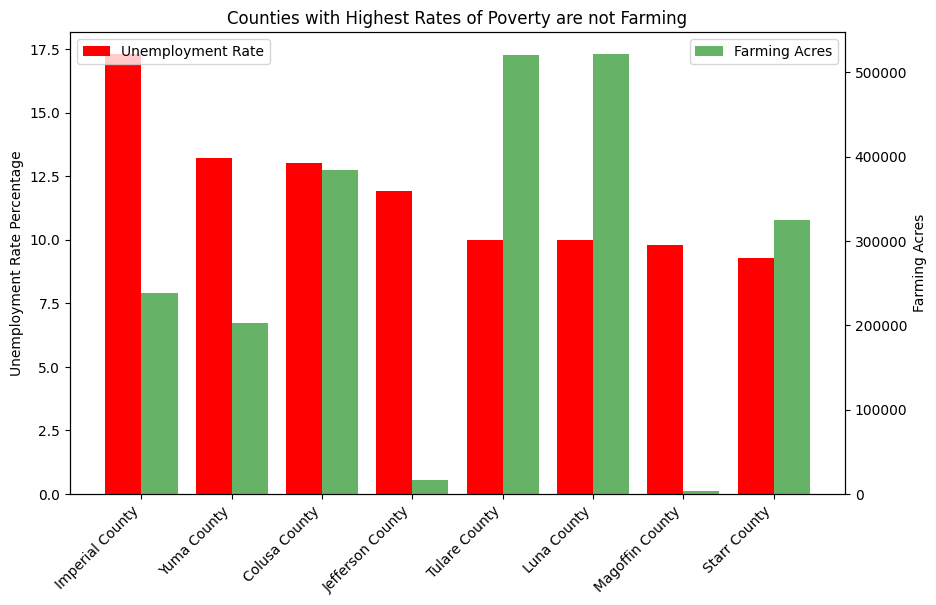

In [433]:
plot1 = pd.read_sql(query4, connection)

fig, ax1 = plt.subplots(figsize=(10, 6))

width = 0.4
x_pos = np.arange(len(plot1['area']))

ax1.bar(x_pos - width/2, plot1['unempl_rt'], width=width, color='red', label='Unemployment Rate')
# ax1.set_xlabel('County')
ax1.set_ylabel('Unemployment Rate Percentage')
ax1.legend(loc='upper left')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(plot1['area'], rotation=45, ha='right')


ax2 = ax1.twinx()
ax2.bar(x_pos + width/2, plot1['acres'], width=width, color='green', label='Farming Acres', alpha=0.6)
ax2.set_ylabel('Farming Acres')
ax2.legend(loc='upper right')


plt.title('Counties with Highest Rates of Poverty are not Farming')

plt.savefig('../plots/Counties with High Poverty Rates')
plt.show()



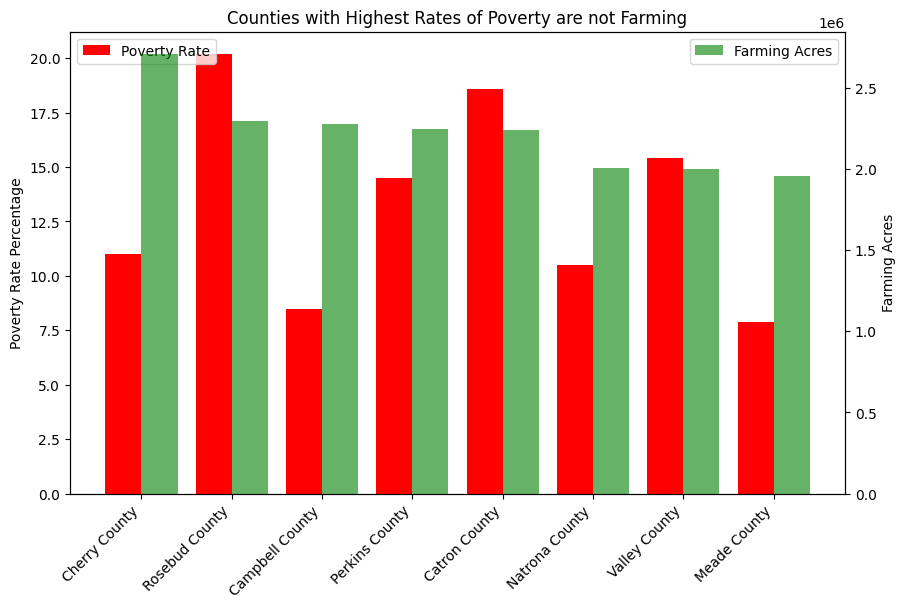

In [434]:
plot1 = pd.read_sql(query5, connection)

fig, ax1 = plt.subplots(figsize=(10, 6))

width = 0.4
x_pos = np.arange(len(plot1['area']))

ax1.bar(x_pos - width/2, plot1['pvty_rt'], width=width, color='red', label='Poverty Rate')
# ax1.set_xlabel('County')
ax1.set_ylabel('Poverty Rate Percentage')
ax1.legend(loc='upper left')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(plot1['area'], rotation=45, ha='right')


ax2 = ax1.twinx()
ax2.bar(x_pos + width/2, plot1['acres'], width=width, color='green', label='Farming Acres', alpha=0.6)
ax2.set_ylabel('Farming Acres')
ax2.legend(loc='upper right')


plt.title('Counties with Highest Rates of Poverty are not Farming')

plt.savefig('../plots/Counties with High Poverty Rates')
plt.show()



#### Prep for Visualizations

#### Visualizations

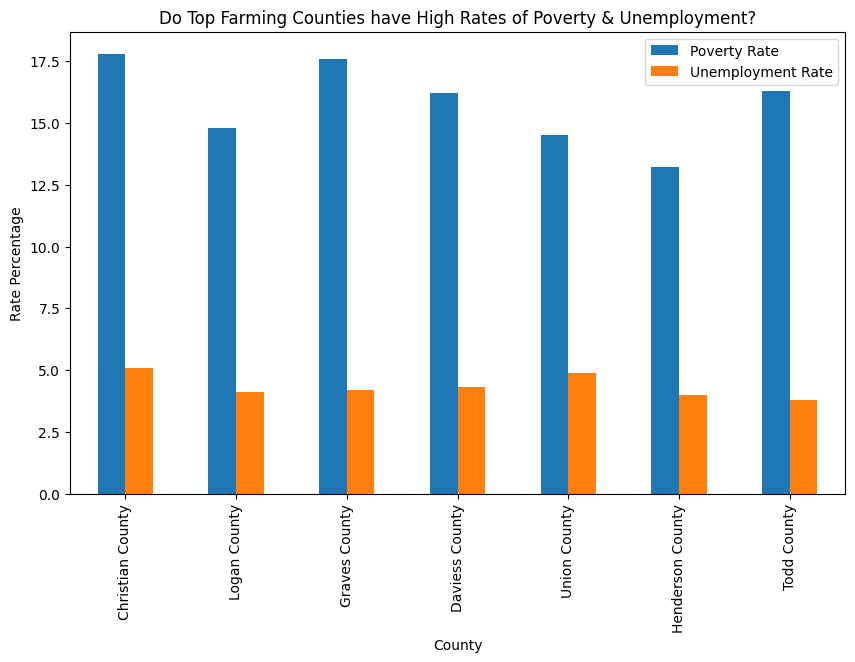

In [435]:
# Comparing Poverty Rates and Unemployment Rates for the Top 7 Farming Counties 

top7_rural_cty.plot.bar(x="County", y=["Poverty Rate", "Unemployment Rate"], figsize=(10,6),
                        title="Do Top Farming Counties have High Rates of Poverty & Unemployment?",
                        ylabel="Rate Percentage")

plt.savefig('../plots/Top Farming Counties Poverty and Unemployment Rates')

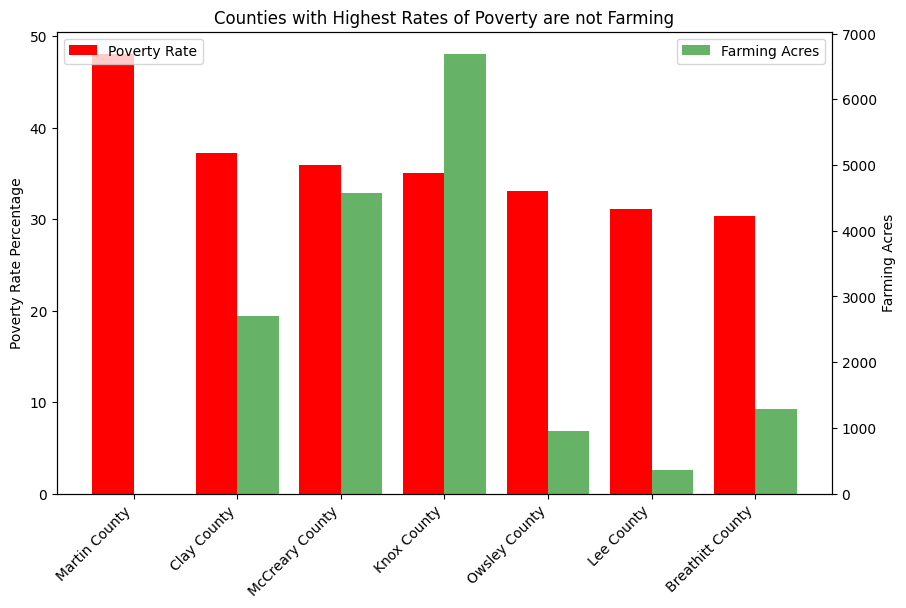

In [436]:

fig, ax1 = plt.subplots(figsize=(10, 6))

width = 0.4
x_pos = np.arange(len(top7_poverty_cty['County']))

ax1.bar(x_pos - width/2, top7_poverty_cty['Poverty Rate'], width=width, color='red', label='Poverty Rate')
# ax1.set_xlabel('County')
ax1.set_ylabel('Poverty Rate Percentage')
ax1.legend(loc='upper left')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(top7_poverty_cty['County'], rotation=45, ha='right')


ax2 = ax1.twinx()
ax2.bar(x_pos + width/2, top7_poverty_cty['Farming Acres'], width=width, color='green', label='Farming Acres', alpha=0.6)
ax2.set_ylabel('Farming Acres')
ax2.legend(loc='upper right')


plt.title('Counties with Highest Rates of Poverty are not Farming')

plt.savefig('../plots/Counties with High Poverty Rates')
plt.show()



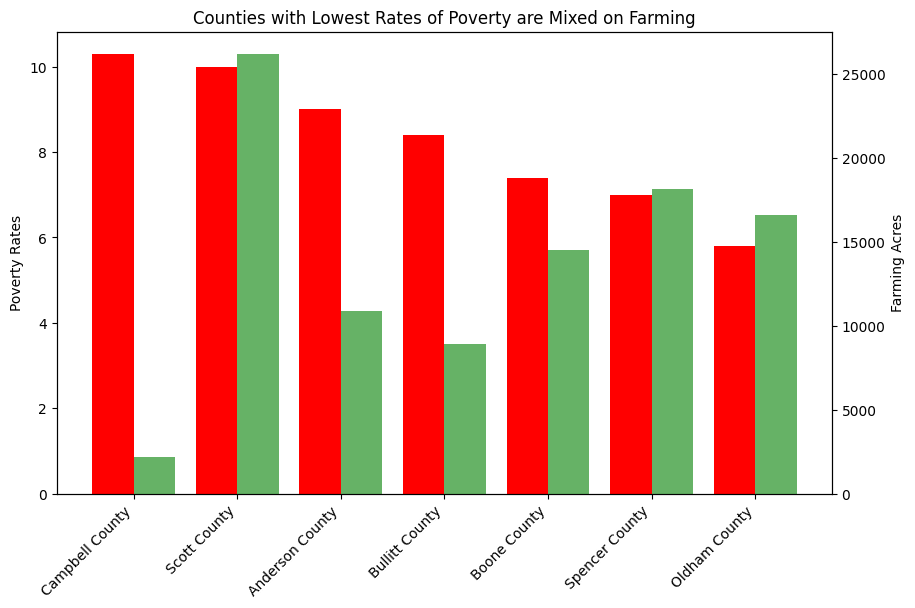

In [437]:
# 
fig, ax1 = plt.subplots(figsize=(10, 6))

width = 0.4
x_pos = np.arange(len(bot7_poverty_cty['County']))

ax1.bar(x_pos - width/2, bot7_poverty_cty['Poverty Rate'], width=width, color='red', label='Poverty Rate')
ax1.set_ylabel('Poverty Rates')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(bot7_poverty_cty['County'], rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.bar(x_pos + width/2, bot7_poverty_cty['Farming Acres'], width=width, color='green', label='Farming Acres', alpha=0.6)
ax2.set_ylabel('Farming Acres')

plt.title('Counties with Lowest Rates of Poverty are Mixed on Farming')

plt.savefig('../plots/Counties with High Poverty Rates not Farming')
plt.show()

